# Validation Visuelle du Slicer PixelOdyssey

In [1]:
import os
import sys
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Configuration des chemins système pour importer notre code modulaire
# On remonte d'un cran pour atteindre la racine du projet
sys.path.append(os.path.abspath(os.path.join("..")))
from src.data.slicer import PlasticImageSlicer

In [7]:
# 2. Définition des dossiers sur ton SSD Samsung (D:)
RAW_DIR = r"E:\PixelOdyssey\dataset\test"
TEST_IMG_DIR = r"E:\PixelOdyssey\dataset\test\test_images"
TEST_LAB_DIR = r"E:\PixelOdyssey\dataset\test\test_labels"

os.makedirs(TEST_IMG_DIR, exist_ok=True)
os.makedirs(TEST_LAB_DIR, exist_ok=True)


In [8]:
# 3. Initialisation du slicer avec tes paramètres de précision
slicer = PlasticImageSlicer(
    tile_size=640, 
    overlap=256, 
    discard_truncated=True  # Notre nouvelle stratégie anti-arêtes droites
)

# Nom de ton image test présente dans ton dossier RAW
# !!! Remplace par le nom d'un fichier réel présent dans ton dossier raw !!!
test_filename = "transect6" 

img_path = os.path.join(RAW_DIR, f"{test_filename}.png")
label_path = os.path.join(RAW_DIR, f"{test_filename}.txt")

# Exécution du découpage
slicer.slice_single_pair(
    img_path=img_path,
    label_path=label_path,
    output_img_dir=TEST_IMG_DIR,
    output_label_dir=TEST_LAB_DIR,
    prefix=test_filename
)


[INFO] Image transect6.png découpée en 36 tuiles (Bordures filtrées: True).


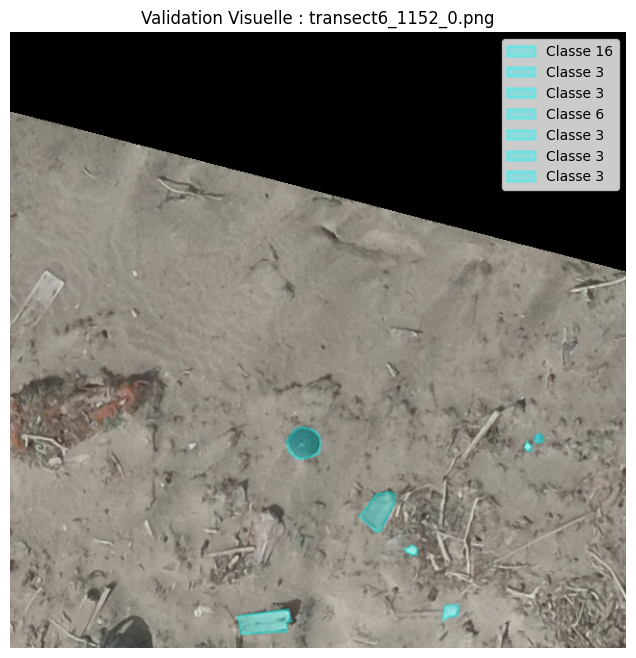

In [15]:
# 4. Visualisation d'une tuile générée pour valider le repositionnement des polygones
# Nous allons chercher la première tuile qui contient une annotation
annotated_tiles = [f for f in os.listdir(TEST_LAB_DIR) if f.endswith(".txt") and os.path.getsize(os.path.join(TEST_LAB_DIR, f)) > 0]

if not annotated_tiles:
    print("[WARN] Aucune tuile avec annotation trouvée. Vérifie que ton image test contient bien des déchets labellisés.")
else:
    # On prend la première tuile annotée pour la démonstration
    target_label = annotated_tiles[2]
    target_img = target_label.replace(".txt", ".png")
    
    tile_img_path = os.path.join(TEST_IMG_DIR, target_img)
    tile_lab_path = os.path.join(TEST_LAB_DIR, target_label)
    
    # Lecture de la tuile (OpenCV BGR -> RGB pour Matplotlib)
    image = cv2.imread(tile_img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image)
    
    # Lecture et superposition du polygone YOLO
    with open(tile_lab_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            class_id = parts[0]
            coords = [float(x) for x in parts[1:]]
            
            # Reconstruction des points (x, y) absolus dans la tuile 640x640
            points = []
            for i in range(0, len(coords), 2):
                x_pixel = coords[i] * w
                y_pixel = coords[i+1] * h
                points.append([x_pixel, y_pixel])
            
            # Dessin du polygone
            polygon_patch = patches.Polygon(
                points, 
                closed=True, 
                linewidth=2, 
                edgecolor="cyan", 
                facecolor="cyan", 
                alpha=0.3, 
                label=f"Classe {class_id}"
            )
            ax.add_patch(polygon_patch)
            
    plt.title(f"Validation Visuelle : {target_img}")
    plt.legend()
    plt.axis("off")
    plt.show()

# Vérification de l'alignement entre tuile et annotation

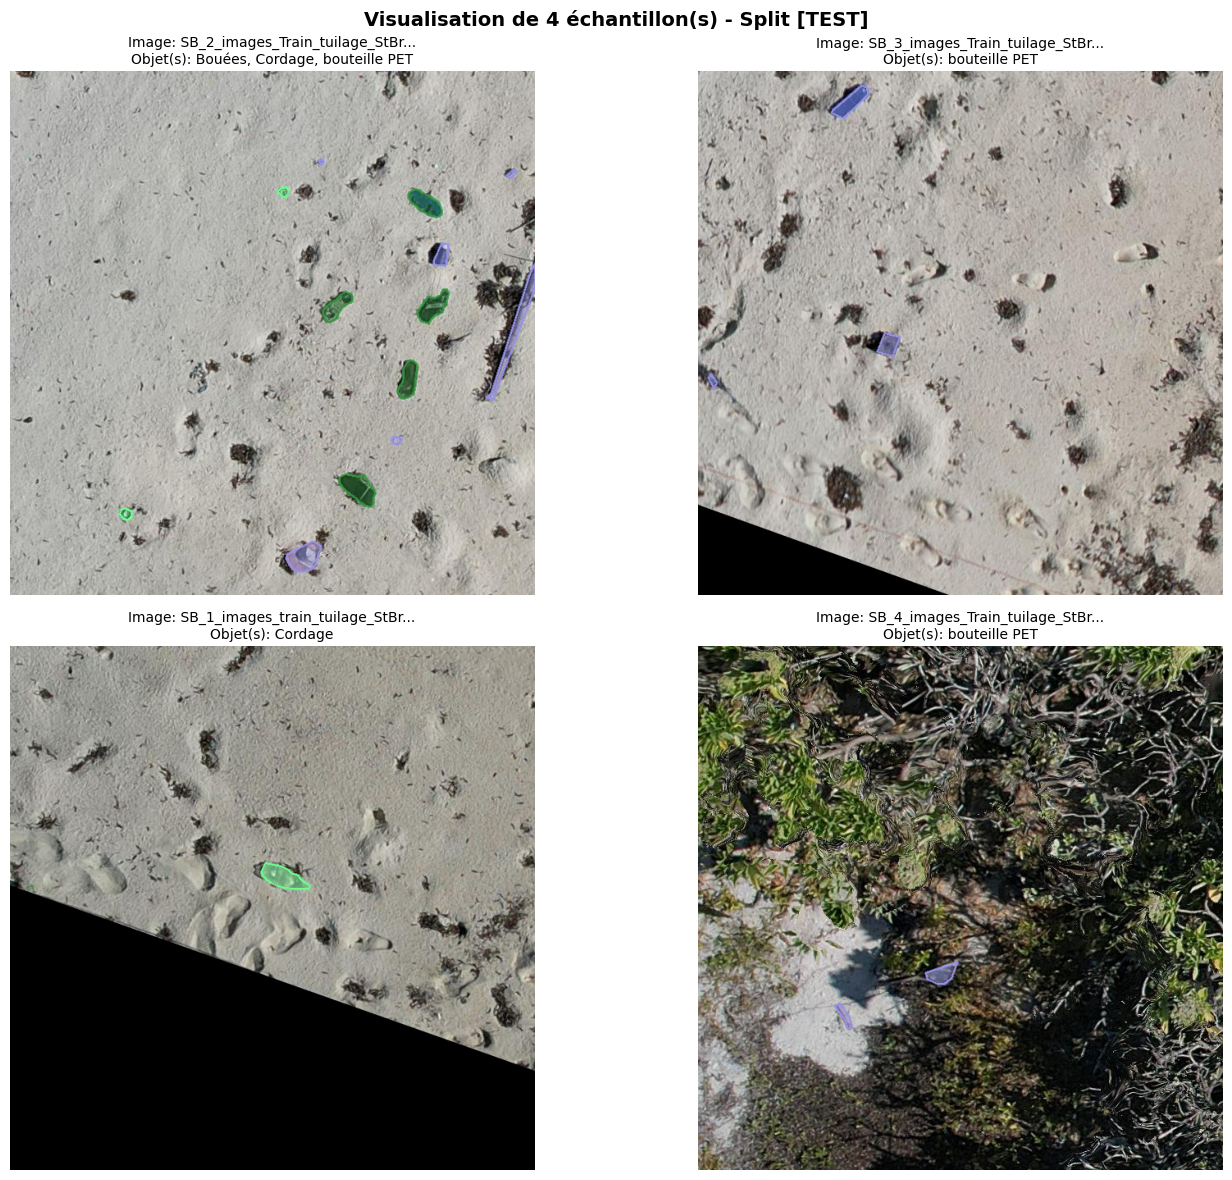

In [3]:
import random
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION ---
# Mapping exact de vos 20 classes
CLASS_NAMES = {
    0: "bouteille PET",
    1: "Cordage",
    2: "Bouées",
    3: "Inconnu",
    4: "Fragments plastique rigide",
    5: "Bouées pieuvre",
    6: "Petit bidon",
    7: "Plastique souple (sac)",
    8: "Mousse expansée",
    9: "Sceau",
    10: "Polystyrene",
    11: "fliflops",
    12: "casques",
    13: "bouchons",
    14: "cagette",
    15: "Bouteille Plastique rigide",
    16: "Morceaux de bois",
    17: "Verre",
    18: "Tissu",
    19: "flotteurs",
}

# Dossier racine du dataset
DATASET_ROOT = Path(r"E:\PixelOdyssey\3. Processed dataset\processed_dataset")

# Splits à inspecter ("train", "val", "test")
SPLIT_TO_SHOW = "test"  # Modifiez par "train" ou "val" selon votre besoin
NUM_SAMPLES = 4  # Nombre d'images aléatoires à afficher


# Palette fixe de couleurs distinctes par classe (format RGB)
def generate_color_palette(num_classes):
    np.random.seed(42)  # Reproductibilité des couleurs
    colors = np.random.randint(50, 255, size=(num_classes, 3), dtype=np.uint8)
    return colors


PALETTE = generate_color_palette(len(CLASS_NAMES))


def plot_random_samples(
    dataset_root: Path, split: str = "test", num_samples: int = 4
):
    images_dir = dataset_root / "images" / split
    labels_dir = dataset_root / "labels" / split

    if not images_dir.exists():
        print(f"❌ Le dossier images n'existe pas : {images_dir}")
        return

    # Récupération de toutes les images PNG/JPG
    image_paths = list(images_dir.glob("*.png")) + list(
        images_dir.glob("*.jpg")
    )

    if not image_paths:
        print(f"⚠️ Aucune image trouvée dans : {images_dir}")
        return

    # Tirage au sort
    selected_paths = random.sample(
        image_paths, min(num_samples, len(image_paths))
    )

    # Préparation du plot
    fig, axes = plt.subplots(
        (num_samples + 1) // 2, 2, figsize=(15, 6 * ((num_samples + 1) // 2))
    )
    axes = axes.flatten() if num_samples > 1 else [axes]

    for idx, img_path in enumerate(selected_paths):
        # 1. Chargement de l'image
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        # Création du calque pour les masques semi-transparents
        overlay = img.copy()

        # 2. Recherche du fichier label correspondant (.txt)
        label_path = labels_dir / f"{img_path.stem}.txt"

        detected_classes_in_image = []

        if label_path.exists():
            with open(label_path, "r") as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) < 7:  # Moins de 3 points
                    continue

                class_id = int(parts[0])
                coords = np.array([float(x) for x in parts[1:]]).reshape(-1, 2)

                # Dénormalisation des coordonnées [0, 1] -> Pixels [W, H]
                coords[:, 0] *= w
                coords[:, 1] *= h
                pts = coords.astype(np.int32)

                # Couleur associée à la classe
                color = PALETTE[class_id % len(PALETTE)].tolist()

                # Dessin du polygone rempli sur l'overlay
                cv2.fillPoly(overlay, [pts], color=color)

                # Dessin du contour (plus visible)
                cv2.polylines(
                    img, [pts], isClosed=True, color=color, thickness=2
                )

                class_name = CLASS_NAMES.get(class_id, f"Cls_{class_id}")
                if class_name not in detected_classes_in_image:
                    detected_classes_in_image.append(class_name)

        # 3. Fusion avec opacité (Alpha Blending : 60% image / 40% masque)
        alpha = 0.4
        final_img = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

        # 4. Affichage
        axes[idx].imshow(final_img)
        labels_str = (
            ", ".join(detected_classes_in_image)
            if detected_classes_in_image
            else "Sans annotation (Fond)"
        )
        axes[idx].set_title(
            f"Image: {img_path.name[:30]}...\nObjet(s): {labels_str}",
            fontsize=10,
        )
        axes[idx].axis("off")

    # Masquer les sous-plots vides si num_samples est impair
    for j in range(idx + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(
        f"Visualisation de {len(selected_paths)} échantillon(s) - Split [{split.upper()}]",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


# --- LANCEUR ---
plot_random_samples(
    DATASET_ROOT, split=SPLIT_TO_SHOW, num_samples=NUM_SAMPLES
)